# IY029: Bidirectional LSTM — Pairwise Same/Different Task

Trains a `LSTMClassifier` **from scratch** on the IY011/IY014 pairwise same/different task.

## Architecture
- `LSTMClassifier(input_size=1, hidden_size=64, num_layers=2, output_size=2)`
- Bidirectional LSTM; last hidden state → FC(128) → FC(64) → FC(2)
- `use_conv1d=False`, `use_attention=False` — plain LSTM baseline
- CrossEntropyLoss (label_smoothing=0.1), Adam, ReduceLROnPlateau, early stopping patience=15

## Data
Same IY011 (2-fold) / IY014 (10-fold) static loaders as all other IY029 pairwise notebooks.
Full concatenated pair `(T, 1)` fed directly — no cropping. Chance = 50%.

## Saves
`IY029_lstm_pairwise_results.json`

In [1]:
import sys
sys.path.insert(0, '../../src')

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

from dataloaders import load_loader_from_disk
from models.lstm import LSTMClassifier

plt.rcParams.update({
    'font.family': 'sans-serif', 'axes.labelsize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 10, 'axes.titlesize': 14,
})

EXP_DIR    = Path('../..')
IY011_ROOT = EXP_DIR / 'experiments/EXP-25-IY011'
IY014_ROOT = EXP_DIR / 'experiments/EXP-26-IY014'

HIDDEN_SIZE = 64
NUM_LAYERS  = 2
DROPOUT     = 0.3
# BPTT stores all T hidden states per sample in GPU memory (O(T × batch)); keep small
# for full-length concatenated pair sequences (~3600+ timesteps).
BATCH_SIZE  = 32
N_EPOCHS    = 100
PATIENCE    = 15
LR          = 1e-3

DATASET_CONFIGS = [
    {
        'name':        'Baseline',
        'iy011_train': IY011_ROOT / 'data'                / 'IY011_static_train.pt',
        'iy011_val':   IY011_ROOT / 'data'                / 'IY011_static_val.pt',
        'iy011_test':  IY011_ROOT / 'data'                / 'IY011_static_test.pt',
        'iy014_train': IY014_ROOT / 'data'                / 'IY014_static_train.pt',
        'iy014_val':   IY014_ROOT / 'data'                / 'IY014_static_val.pt',
        'iy014_test':  IY014_ROOT / 'data'                / 'IY014_static_test.pt',
    },
    {
        'name':        'Mu',
        'iy011_train': IY011_ROOT / 'data_mu_variation'   / 'IY011_static_train.pt',
        'iy011_val':   IY011_ROOT / 'data_mu_variation'   / 'IY011_static_val.pt',
        'iy011_test':  IY011_ROOT / 'data_mu_variation'   / 'IY011_static_test.pt',
        'iy014_train': IY011_ROOT / 'data_mu_variation'   / 'IY014_static_train.pt',
        'iy014_val':   IY011_ROOT / 'data_mu_variation'   / 'IY014_static_val.pt',
        'iy014_test':  IY011_ROOT / 'data_mu_variation'   / 'IY014_static_test.pt',
    },
    {
        'name':        'CV',
        'iy011_train': IY011_ROOT / 'data_cv_variation'   / 'IY011_static_train.pt',
        'iy011_val':   IY011_ROOT / 'data_cv_variation'   / 'IY011_static_val.pt',
        'iy011_test':  IY011_ROOT / 'data_cv_variation'   / 'IY011_static_test.pt',
        'iy014_train': IY014_ROOT / 'data_cv_variation'   / 'IY014_static_train.pt',
        'iy014_val':   IY014_ROOT / 'data_cv_variation'   / 'IY014_static_val.pt',
        'iy014_test':  IY014_ROOT / 'data_cv_variation'   / 'IY014_static_test.pt',
    },
    {
        'name':        'T_ac',
        'iy011_train': IY011_ROOT / 'data_t_ac_variation' / 'IY011_static_train.pt',
        'iy011_val':   IY011_ROOT / 'data_t_ac_variation' / 'IY011_static_val.pt',
        'iy011_test':  IY011_ROOT / 'data_t_ac_variation' / 'IY011_static_test.pt',
        'iy014_train': IY014_ROOT / 'data_t_ac_variation' / 'IY014_static_train.pt',
        'iy014_val':   IY014_ROOT / 'data_t_ac_variation' / 'IY014_static_val.pt',
        'iy014_test':  IY014_ROOT / 'data_t_ac_variation' / 'IY014_static_test.pt',
    },
]
DS_NAMES = [cfg['name'] for cfg in DATASET_CONFIGS]
print(f'Datasets: {DS_NAMES}')

Datasets: ['Baseline', 'Mu', 'CV', 'T_ac']


## Helpers

In [2]:
def load_split(pt_path):
    """Load a .pt static loader → (X_np float32, y_np int64) numpy arrays."""
    loader = load_loader_from_disk(pt_path, batch_size=2048)
    Xs, ys = [], []
    for X, y in loader:
        Xs.append(X.numpy())
        ys.append(y.numpy().ravel())
    return np.concatenate(Xs), np.concatenate(ys).astype(np.int64)


def make_loader(X_np, y_np, shuffle=True):
    """Wrap numpy arrays in a DataLoader; y must be int64 for CrossEntropyLoss."""
    ds = torch.utils.data.TensorDataset(
        torch.tensor(X_np, dtype=torch.float32),
        torch.tensor(y_np, dtype=torch.long),
    )
    return torch.utils.data.DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)


def train_and_eval(X_tr, y_tr, X_va, y_va, X_te, y_te):
    """
    Instantiate a fresh LSTMClassifier and train with built-in train_model().
    Returns (test_accuracy, train_loss_curve).
    """
    model = LSTMClassifier(
        input_size=1,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        output_size=2,
        dropout_rate=DROPOUT,
        learning_rate=LR,
        use_conv1d=False,
        use_attention=False,
        bidirectional=True,
        verbose=False,
    )
    tr_loader = make_loader(X_tr, y_tr, shuffle=True)
    va_loader = make_loader(X_va, y_va, shuffle=False)
    te_loader = make_loader(X_te, y_te, shuffle=False)

    history = model.train_model(tr_loader, va_loader,
                                epochs=N_EPOCHS, patience=PATIENCE)
    te_acc = model.evaluate(te_loader)
    return te_acc, history['train_loss']

## Load Data & Train

In [3]:
results     = {}
loss_curves = {}

for cfg in DATASET_CONFIGS:
    name = cfg['name']
    results[name]     = {}
    loss_curves[name] = {}
    print(f'\n=== {name} ===')

    for fold in ('iy011', 'iy014'):
        print(f'  {fold}: loading...', end=' ', flush=True)
        X_tr, y_tr = load_split(cfg[f'{fold}_train'])
        X_va, y_va = load_split(cfg[f'{fold}_val'])
        X_te, y_te = load_split(cfg[f'{fold}_test'])
        print(f'train={X_tr.shape}  val={X_va.shape}  test={X_te.shape}  |  training...', flush=True)

        acc, lc = train_and_eval(X_tr, y_tr, X_va, y_va, X_te, y_te)
        results[name][fold]     = acc
        loss_curves[name][fold] = lc
        print(f'  test acc = {acc:.4f}  (trained {len(lc)} epochs)')

print('\nDone.')


=== Baseline ===
  iy011: loading... 📂 Loading static data from ../../experiments/EXP-25-IY011/data/IY011_static_train.pt...
📂 Loading static data from ../../experiments/EXP-25-IY011/data/IY011_static_val.pt...
📂 Loading static data from ../../experiments/EXP-25-IY011/data/IY011_static_test.pt...
train=(3000, 3623, 1)  val=(600, 3623, 1)  test=(600, 3623, 1)  |  training...
  test acc = 0.5367  (trained 33 epochs)
  iy014: loading... 📂 Loading static data from ../../experiments/EXP-26-IY014/data/IY014_static_train.pt...
📂 Loading static data from ../../experiments/EXP-26-IY014/data/IY014_static_val.pt...
📂 Loading static data from ../../experiments/EXP-26-IY014/data/IY014_static_test.pt...
train=(3000, 3623, 1)  val=(600, 3623, 1)  test=(600, 3623, 1)  |  training...
  test acc = 0.5067  (trained 17 epochs)

=== Mu ===
  iy011: loading... 📂 Loading static data from ../../experiments/EXP-25-IY011/data_mu_variation/IY011_static_train.pt...
📂 Loading static data from ../../experiments/EX

In [4]:
_save_path = Path('IY029_lstm_pairwise_results.json')
if _save_path.exists():
    with open(_save_path) as _f:
        results = json.load(_f)
    print(f'Loaded existing {_save_path} (skipping overwrite)')
else:
    with open(_save_path, 'w') as _f:
        json.dump(
            {ds: {fold: float(results[ds][fold]) for fold in ('iy011', 'iy014')}
             for ds in DS_NAMES},
            _f, indent=2,
        )
    print(f'Saved {_save_path}')

Saved IY029_lstm_pairwise_results.json


## Results

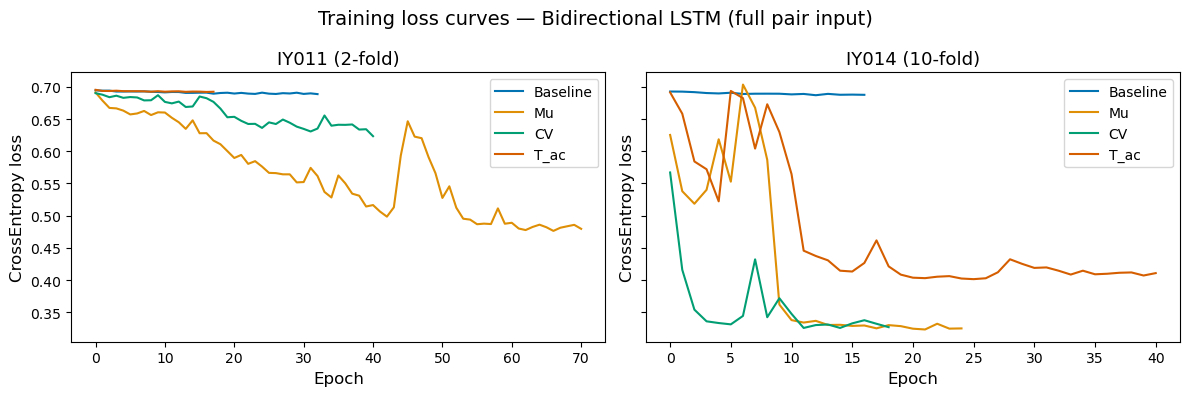

Saved IY029_lstm_pairwise_loss.png


In [5]:
palette   = sns.color_palette('colorblind')
ds_colors = {n: palette[i] for i, n in enumerate(DS_NAMES)}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, fold, fold_title in [
    (axes[0], 'iy011', 'IY011 (2-fold)'),
    (axes[1], 'iy014', 'IY014 (10-fold)'),
]:
    for name in DS_NAMES:
        ax.plot(loss_curves[name][fold], color=ds_colors[name], label=name, lw=1.5)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('CrossEntropy loss', fontsize=12)
    ax.set_title(fold_title, fontsize=13)
    ax.legend(fontsize=10)
fig.suptitle('Training loss curves — Bidirectional LSTM (full pair input)', fontsize=14)
plt.tight_layout()
plt.savefig('IY029_lstm_pairwise_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved IY029_lstm_pairwise_loss.png')

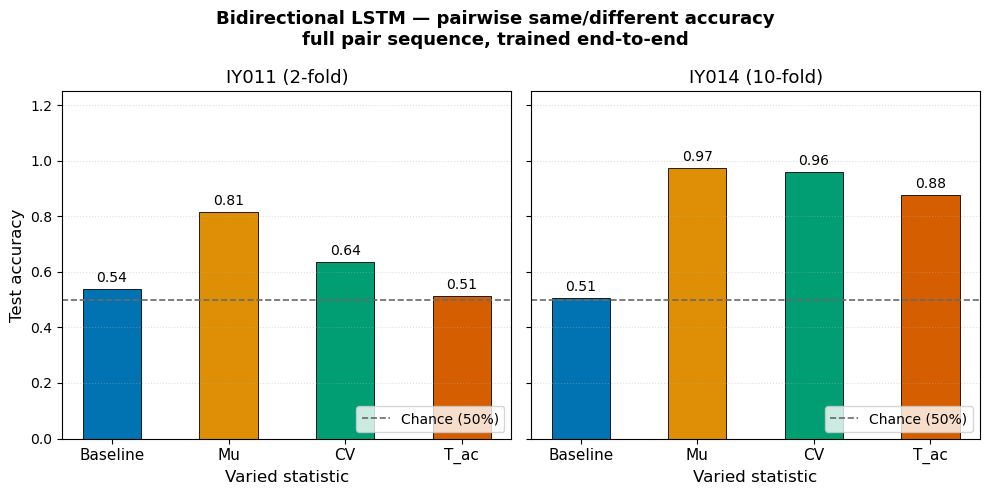

Saved IY029_lstm_pairwise_acc.png


In [6]:
colors = [palette[i] for i in range(len(DS_NAMES))]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
x     = np.arange(len(DS_NAMES))
width = 0.5

for ax, fold_key, fold_title in [
    (axes[0], 'iy011', 'IY011 (2-fold)'),
    (axes[1], 'iy014', 'IY014 (10-fold)'),
]:
    accs = [results[n][fold_key] for n in DS_NAMES]
    bars = ax.bar(x, accs, width, color=colors, edgecolor='black', linewidth=0.6)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)
    ax.axhline(0.5, color='dimgrey', linestyle='--', linewidth=1.2, label='Chance (50%)')
    ax.set_xticks(x)
    ax.set_xticklabels(DS_NAMES, fontsize=11)
    ax.set_xlabel('Varied statistic', fontsize=12)
    ax.set_ylim(0, 1.25)
    ax.set_title(fold_title, fontsize=13)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(axis='y', linestyle=':', alpha=0.4)

axes[0].set_ylabel('Test accuracy', fontsize=12)
fig.suptitle('Bidirectional LSTM — pairwise same/different accuracy\n'
             'full pair sequence, trained end-to-end',
             fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig('IY029_lstm_pairwise_acc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved IY029_lstm_pairwise_acc.png')

In [7]:
import pandas as pd
rows = []
for n in DS_NAMES:
    rows.append({
        'Dataset':         n,
        '2-fold (IY011)':  results[n]['iy011'],
        '10-fold (IY014)': results[n]['iy014'],
        'Mean':            np.mean([results[n]['iy011'], results[n]['iy014']]),
    })
df = pd.DataFrame(rows).set_index('Dataset')
pd.set_option('display.float_format', '{:.3f}'.format)
print(df.to_string())

          2-fold (IY011)  10-fold (IY014)  Mean
Dataset                                        
Baseline           0.537            0.507 0.522
Mu                 0.813            0.972 0.893
CV                 0.635            0.958 0.797
T_ac               0.512            0.877 0.694
